In [2]:
import struct
import numpy as np
from collections import defaultdict

DBF_PATH = "data/357PcTehuacan.DBF"

# Vehicle classes, from Mexican SCT NOM-012-SCT-2
N_AXLES = {"C2": 2, "C3": 3, "T3-S2": 5, "T3-S3": 6, "T3-S2-R4": 9}

In [3]:
def parse_dbf(path):
    """reads dBase file and returns a list of dicts"""
    with open(path, "rb") as f:
        data = f.read()

    n_records = struct.unpack("<I", data[4:8])[0]
    header_len = struct.unpack("<H", data[8:10])[0]
    record_len = struct.unpack("<H", data[10:12])[0]

    fields = []
    pos = 32
    while data[pos] != 0x0D:
        name = data[pos:pos+11].rstrip(b"\x00").decode("latin-1", errors="replace")
        ftype = chr(data[pos+11])
        flen = data[pos+16]
        fields.append((name, ftype, flen))
        pos += 32

    offsets = []
    o = 1
    for name, ftype, flen in fields:
        offsets.append((name, ftype, flen, o))
        o += flen
    field_idx = {name: i for i, (name, _, _, _) in enumerate(offsets)}

    def get(rec, fname):
        name, ftype, flen, o = offsets[field_idx[fname]]
        raw = rec[o:o+flen].rstrip(b" \x00").decode("latin-1", errors="replace").strip()
        if ftype == "N":
            try: return float(raw) if raw else None
            except ValueError: return None
        return raw

    records = []
    rs = header_len
    for i in range(n_records):
        rec = data[rs + i*record_len : rs + (i+1)*record_len]
        if rec[0:1] == b"*":
            continue
        records.append({fname: get(rec, fname) for fname, _, _ in [(f[0], None, None) for f in fields]})
    return records

records = parse_dbf(DBF_PATH)
print(f"Total records: {len(records):,}")

Total records: 16,165


In [4]:
# Group axle weight vectors by vehicle class
by_class = defaultdict(list)
for rec in records:
    tipo = rec.get("TIPO", "")
    if tipo not in N_AXLES:
        continue
    n_ax = N_AXLES[tipo]
    axles = []
    for k in range(1, n_ax + 1):
        v = rec.get(f"E{k:02d}")
        axles.append(v if (v is not None and v > 0) else 0.0)
    if sum(axles) <= 0:
        continue
    by_class[tipo].append(axles)

for tipo in N_AXLES:
    print(f"{tipo:<10} {len(by_class[tipo]):>5} weighed records")

C2          1063 weighed records
C3           994 weighed records
T3-S2       1327 weighed records
T3-S3        295 weighed records
T3-S2-R4     704 weighed records


In [5]:
# avg and std for each class

print("data for each class")
print("=" * 72)

for tipo in ["C2", "C3", "T3-S2", "T3-S3", "T3-S2-R4"]:
    arr = np.array(by_class[tipo])
    n = arr.shape[0]
    pbv_mean = arr.sum(axis=1).mean()
    pbv_max = arr.sum(axis=1).max()
    means = arr.mean(axis=0)
    stds = arr.std(axis=0)

    print(f"\n# {tipo}: n={n} weighed records, PBV mean={pbv_mean/1000:.1f} t, max={pbv_max/1000:.1f} t")
    means_list = ", ".join(f"{m:.0f}" for m in means)
    stds_list = ", ".join(f"{s:.0f}" for s in stds)
    print(f'  "Pi_mean": np.array([{means_list}]),')
    print(f'  "Pi_std":  np.array([{stds_list}]),')

data for each class

# C2: n=1063 weighed records, PBV mean=7.2 t, max=44.7 t
  "Pi_mean": np.array([2814, 4402]),
  "Pi_std":  np.array([1371, 2147]),

# C3: n=994 weighed records, PBV mean=12.4 t, max=45.8 t
  "Pi_mean": np.array([3460, 4382, 4510]),
  "Pi_std":  np.array([1770, 2229, 2304]),

# T3-S2: n=1327 weighed records, PBV mean=23.9 t, max=61.0 t
  "Pi_mean": np.array([2690, 5145, 5387, 5149, 5556]),
  "Pi_std":  np.array([851, 1624, 1699, 1627, 1782]),

# T3-S3: n=295 weighed records, PBV mean=29.8 t, max=63.6 t
  "Pi_mean": np.array([3294, 5102, 5272, 5236, 5420, 5451]),
  "Pi_std":  np.array([1010, 1557, 1605, 1607, 1692, 1711]),

# T3-S2-R4: n=704 weighed records, PBV mean=56.1 t, max=92.4 t
  "Pi_mean": np.array([2789, 6854, 6863, 6510, 6516, 6500, 6503, 6445, 7130]),
  "Pi_std":  np.array([1077, 2574, 2556, 2448, 2436, 2433, 2440, 2404, 2809]),


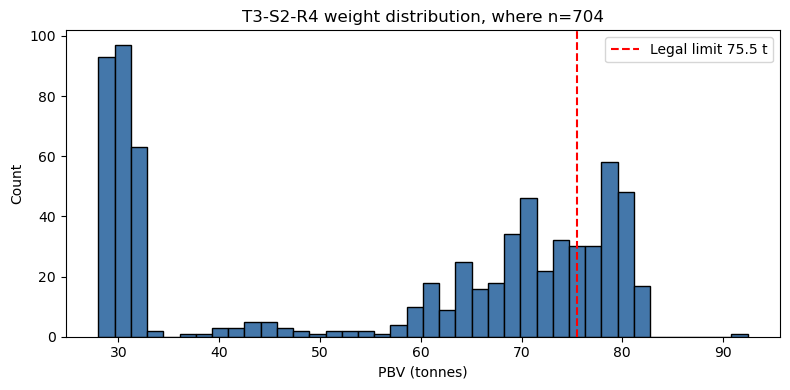

T3-S2-R4 records over legal limit: 171 / 704 (24.3%)
Max observed PBV: 92.4 t  (1.22x legal)


In [12]:
# T3-S2-R4 is the biggest class in the mexican code. this was just to visualize its distributions from empirical data. 
import matplotlib.pyplot as plt

t3 = np.array(by_class["T3-S2-R4"])
pbv = t3.sum(axis=1) / 1000  # tonnes

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pbv, bins=40, edgecolor="black", color="#4477AA")
ax.axvline(75.5, linestyle="--", color="red", label="Legal limit 75.5 t")
ax.set_xlabel("PBV (tonnes)")
ax.set_ylabel("Count")
ax.set_title(f"T3-S2-R4 weight distribution, where n={len(pbv)}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"T3-S2-R4 records over legal limit: {(pbv > 75.5).sum()} / {len(pbv)} ({100*(pbv > 75.5).mean():.1f}%)")
print(f"Max observed PBV: {pbv.max():.1f} t  ({pbv.max()/75.5:.2f}x legal)")